# A/B Testing Sistem Rekomendasi Jurusan Siswa SMA
---

# Latar Belakang

Pemilihan jurusan merupakan salah satu keputusan penting bagi siswa SMA karena dapat memengaruhi arah pendidikan dan karier di masa depan. Namun, banyak siswa mengalami kesulitan dalam menentukan jurusan yang sesuai dengan kemampuan akademik dan karakteristik pribadinya.

Untuk membantu proses tersebut, dikembangkan sistem rekomendasi jurusan berbasis machine learning yang memanfaatkan data siswa, seperti nilai akademik dan karakteristik pendukung lainnya. Akan tetapi, belum diketahui apakah informasi non-akademik seperti kebiasaan belajar, aktivitas ekstrakurikuler, tingkat kehadiran, pekerjaan paruh waktu, dan gender dapat meningkatkan kualitas rekomendasi yang dihasilkan.

Oleh karena itu, dilakukan A/B Testing untuk membandingkan performa dua model rekomendasi jurusan. Model A menggunakan nilai akademik sebagai fitur utama, sedangkan Model B menggunakan nilai akademik serta karakteristik siswa. Hasil pengujian diharapkan dapat memberikan informasi mengenai kombinasi fitur yang paling efektif dalam menghasilkan rekomendasi jurusan yang akurat.



## SMART Question
SMART Question digunakan untuk memastikan eksperimen A/B Testing memiliki tujuan yang jelas dan terukur.

## Specific (Spesifik)

Apakah penambahan karakteristik siswa seperti gender, kebiasaan belajar mandiri, aktivitas ekstrakurikuler, tingkat kehadiran, dan pekerjaan paruh waktu dapat meningkatkan performa model rekomendasi jurusan dibandingkan penggunaan nilai akademik saja?

## Measurable (Terukur)

Performa model diukur menggunakan Accuracy, Precision, Recall, dan F1-Score.

## Action-Oriented (Berorientasi Aksi)

Hasil eksperimen digunakan untuk menentukan fitur yang perlu digunakan dalam sistem rekomendasi jurusan siswa.

## Relevant (Relevan)

Pemilihan jurusan tidak hanya dipengaruhi oleh kemampuan akademik, tetapi juga karakteristik dan kebiasaan siswa.

## Time-Bound (Terikat Waktu)

Evaluasi dilakukan menggunakan dataset historis sebanyak 6.000 siswa yang telah melalui tahap data preparation.

### Pertanyaan A/B Testing

Apakah model rekomendasi jurusan yang menggunakan nilai akademik dan karakteristik siswa menghasilkan performa yang lebih baik dibandingkan model yang hanya menggunakan nilai akademik?


## Pertanyaan A/B Testing
Apakah penambahan karakteristik siswa dapat meningkatkan performa model rekomendasi jurusan?




# Hipotesis
### H0 (Hipotesis Nol)

Tidak terdapat peningkatan performa model rekomendasi jurusan setelah penambahan fitur karakteristik siswa berupa gender, weekly self study hours, extracurricular activities, absence days, dan part time job.

### H1 (Hipotesis Alternatif)

Terdapat peningkatan performa model rekomendasi jurusan setelah penambahan fitur karakteristik siswa berupa gender, weekly self study hours, extracurricular activities, absence days, dan part time job.

In [ ]:
#import library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [ ]:
#load data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Dataset:
df_capstone = pd.read_csv('/content/drive/MyDrive/data_jurusan.csv')

df_capstone.head()

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,...,major_group,average_score,performance_category,sains_score,sosial_score,bahasa_score,gender_Female,gender_Male,career_encoded,major_group_encoded
0,Male,0,0.3,0,0.54,Lawyer,0.425532,0.62,0.86,0.94,...,Sosial & Hukum,0.617838,Sedang,0.625731,0.651685,0.612245,0,1,9,3
1,Female,0,0.2,0,0.94,Doctor,0.787234,0.72,0.92,1.00,...,Sains & Kesehatan,0.872703,Tinggi,0.918129,0.741573,0.775510,1,0,6,1
2,Female,0,0.9,1,0.26,Government Officer,0.595745,0.94,0.90,0.92,...,Sosial & Hukum,0.737568,Tinggi,0.690058,0.910112,0.551020,1,0,8,3
3,Female,0,0.5,0,0.06,Artist,0.382979,0.48,0.76,0.60,...,Seni & Kreatif,0.528919,Sedang,0.637427,0.561798,0.265306,1,0,1,2
4,Male,0,0.5,0,0.20,Social Network Studies,0.659574,0.54,0.30,0.30,...,Sosial & Hukum,0.413243,Rendah,0.438596,0.483146,0.489796,0,1,12,3


In [ ]:
df_capstone.columns


Index(['gender', 'part_time_job', 'absence_days', 'extracurricular_activities',
       'weekly_self_study_hours', 'career_aspiration', 'math_score',
       'history_score', 'physics_score', 'chemistry_score', 'biology_score',
       'english_score', 'geography_score', 'major_group', 'average_score',
       'performance_category', 'sains_score', 'sosial_score', 'bahasa_score',
       'gender_Female', 'gender_Male', 'career_encoded',
       'major_group_encoded'],
      dtype='object')

In [ ]:
y = df_capstone["major_group_encoded"]

# Eksperimen A (baseline)
note: Hanya nilai akademik saja

In [ ]:
#Eksperimen A
X_A = df_capstone[
  [
"math_score",
"history_score",
"physics_score",
"chemistry_score",
"biology_score",
"english_score",
"geography_score",
"sains_score",
"sosial_score",
"bahasa_score"
  ]
]

Model A menggunakan nilai akademik siswa sebagai dasar rekomendasi jurusan.

In [ ]:
#Split Data
from sklearn.model_selection import train_test_split

y = df_capstone["major_group_encoded"]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Training model A
from sklearn.ensemble import RandomForestClassifier

model_A = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_A.fit(
    X_train_A,
    y_train_A
)

pred_A = model_A.predict(
    X_test_A
)

In [ ]:
#Evaluasi A
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc_A = accuracy_score(
    y_test_A,
    pred_A
)

prec_A = precision_score(
    y_test_A,
    pred_A,
    average="weighted"
)

rec_A = recall_score(
    y_test_A,
    pred_A,
    average="weighted"
)

f1_A = f1_score(
    y_test_A,
    pred_A,
    average="weighted"
)

print("Accuracy :", acc_A)
print("Precision:", prec_A)
print("Recall   :", rec_A)
print("F1 Score :", f1_A)

Accuracy : 0.97
Precision: 0.9702657203345256
Recall   : 0.97
F1 Score : 0.9700804209639743


# Eksperimen B

In [ ]:
#Eksperimen B
X_B = df_capstone[
    [
        "math_score",
        "history_score",
        "physics_score",
        "chemistry_score",
        "biology_score",
        "english_score",
        "geography_score",
        "weekly_self_study_hours",
        "extracurricular_activities",
        "absence_days",
        "part_time_job",
        "gender_Female",
        "gender_Male"
    ]
]

Model B menggunakan nilai akademik dan karakteristik siswa seperti aspirasi karier, kebiasaan belajar, aktivitas ekstrakurikuler, serta gender.

In [ ]:
#Split data B
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Training data B
model_B = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_B.fit(
    X_train_B,
    y_train_B
)

pred_B = model_B.predict(
    X_test_B
)

In [ ]:
#Evaluasi B
acc_B = accuracy_score(
    y_test_B,
    pred_B
)

prec_B = precision_score(
    y_test_B,
    pred_B,
    average="weighted"
)

rec_B = recall_score(
    y_test_B,
    pred_B,
    average="weighted"
)

f1_B = f1_score(
    y_test_B,
    pred_B,
    average="weighted"
)

print("Accuracy :", acc_B)
print("Precision:", prec_B)
print("Recall   :", rec_B)
print("F1 Score :", f1_B)

Accuracy : 0.975
Precision: 0.9752331675264063
Recall   : 0.975
F1 Score : 0.975011660978798


# Tabel Hasil

In [ ]:
hasil_ab = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Model A":[
        acc_A,
        prec_A,
        rec_A,
        f1_A
    ],
    "Model B":[
        acc_B,
        prec_B,
        rec_B,
        f1_B
    ]
})

hasil_ab

,Metric,Model A,Model B
0,Accuracy,0.970000,0.975000
1,Precision,0.970266,0.975233
2,Recall,0.970000,0.975000
3,F1 Score,0.970080,0.975012


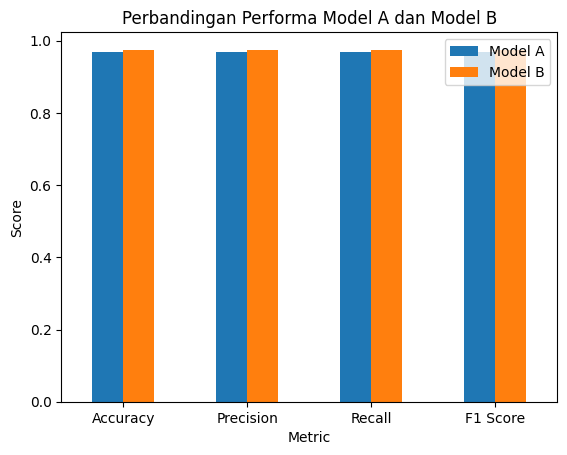

In [ ]:
#visualisasi
hasil_plot = hasil_ab.set_index("Metric")

hasil_plot.plot(kind="bar")

plt.title("Perbandingan Performa Model A dan Model B")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)

plt.show()

## Keputusan Hipotesis

H0 : Penambahan fitur non-akademik tidak meningkatkan performa model rekomendasi jurusan.

H1 : Penambahan fitur non-akademik meningkatkan performa model rekomendasi jurusan.

### Kesimpulan Hasil

Accuracy Model A = 97,00%

Accuracy Model B = 97,50%

Karena Model B menunjukkan performa yang lebih baik dibandingkan Model A pada seluruh metrik evaluasi, maka H0 ditolak dan H1 diterima.

Berdasarkan hasil A/B Testing, Model B menghasilkan performa yang lebih baik dibandingkan Model A pada seluruh metrik evaluasi. Model B memperoleh Accuracy sebesar 97,50%, sedangkan Model A memperoleh Accuracy sebesar 97,00%.

Hasil ini menunjukkan bahwa penambahan fitur non-akademik seperti gender, kebiasaan belajar, aktivitas ekstrakurikuler, tingkat kehadiran, dan pekerjaan paruh waktu dapat meningkatkan kualitas rekomendasi jurusan siswa.

Oleh karena itu, Model B dipilih sebagai model terbaik untuk digunakan pada sistem rekomendasi jurusan siswa SMA karena mampu memberikan hasil prediksi yang lebih akurat dan lebih representatif terhadap karakteristik siswa.


## Analisis Feature Importance
Analisis ini dilakukan untuk mengetahui fitur mana yang paling berpengaruh dalam proses rekomendasi jurusan.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_B.columns,
    'Importance': model_B.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,weekly_self_study_hours,0.162266
0,math_score,0.150228
4,biology_score,0.112537
2,physics_score,0.094357
1,history_score,0.090268
3,chemistry_score,0.089764
5,english_score,0.087102
6,geography_score,0.078886
9,absence_days,0.076582
10,part_time_job,0.016245


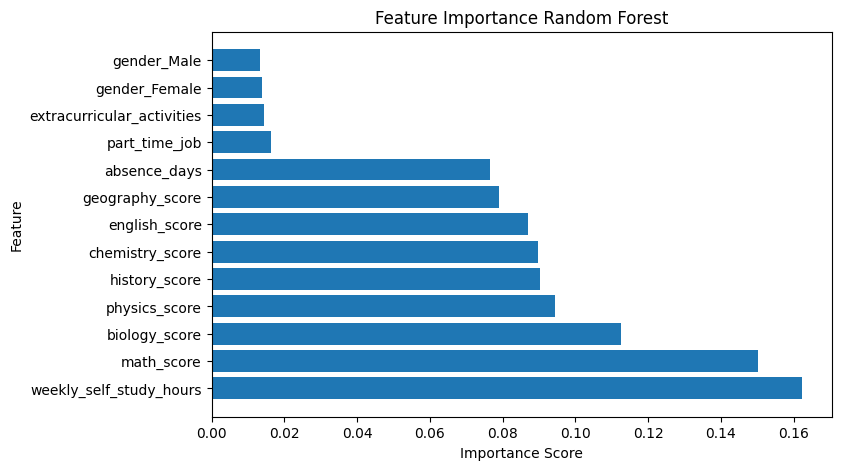

In [ ]:
#Visualisasi
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance Random Forest")

plt.show()

## Confusion Matrix

Confusion Matrix digunakan untuk melihat kemampuan model dalam mengklasifikasikan jurusan siswa secara benar.

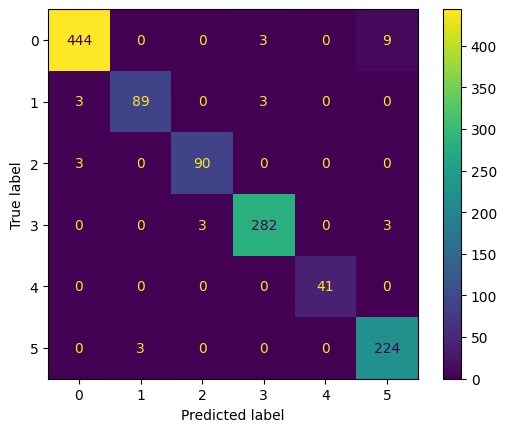

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_B,
    pred_B
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

## Analisi Peningkatan Model

In [ ]:
improvement = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Increase (%)":[
        (acc_B-acc_A)*100,
        (prec_B-prec_A)*100,
        (rec_B-rec_A)*100,
        (f1_B-f1_A)*100
    ]
})

improvement

,Metric,Increase (%)
0,Accuracy,0.500000
1,Precision,0.496745
2,Recall,0.500000
3,F1 Score,0.493124


In [ ]:
# Persentase Peningkatan Accuracy
improvement_acc = (
    (acc_B - acc_A)
    / acc_A
) * 100

print(improvement_acc)

0.5154639175257737
